In [295]:
#Task 1 — Data Loading, Merging & Deep Exploration

In [296]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [297]:
# Loading dataset
df = pd.read_csv(r"C:\Users\sohai\Downloads\train.csv")
df_original = df.copy() ## Create a backup copy incase

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [298]:
# Displaying Dataset
print("First 10 Rows")
display(df.head(10))

First 10 Rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [299]:
# dataset shape 
print("Dataset Shape")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Dataset Shape
Rows : 9800
Columns : 18


In [300]:
#Dataset Information
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   f

In [301]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].head())


  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [302]:
# Year
df["Year"] = df["Order Date"].dt.year

# Month
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day of Week
df["Day"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [303]:
def season(month):

    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [304]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week              0
Day               0
Quarter           0
Season            0
dtype: int64


In [305]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
0


In [306]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week                     UInt32
Day                      object
Quarter                   int32
Season                   object
dtype: object


In [307]:
weekly_sales = df.groupby( pd.Grouper(key="Order Date",freq="W"))["Sales"].sum().reset_index()
display(weekly_sales.head())

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [308]:
monthly_sales = df.groupby( pd.Grouper(key="Order Date",freq="M"))["Sales"].sum().reset_index()
display(monthly_sales.head())

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [309]:
# Ques 1 : Which product category generates the highest total revenue? 
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


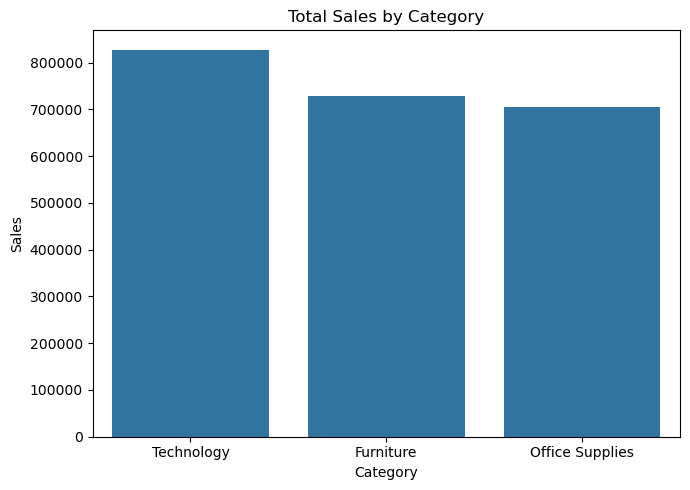

In [310]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot( x=category_sales.index, y=category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("category_sales.png")
plt.show()

In [311]:
# Ques 2 : Which region has the most consistent sales growth?
region_sales = df.groupby(["Year","Region"])["Sales"].sum().unstack()
print(region_sales)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


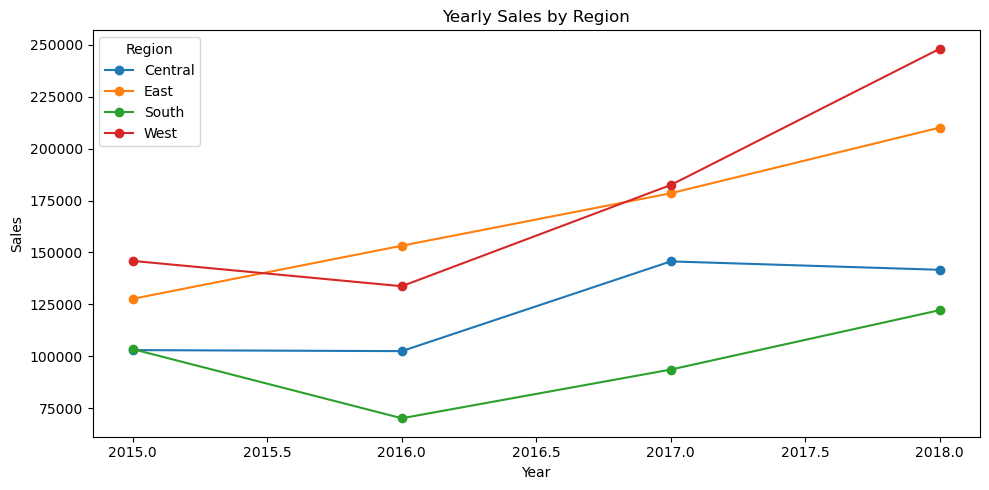

In [312]:
region_sales.plot(figsize=(10,5), marker="o")
plt.title("Yearly Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("region_growth.png")
plt.show()

In [313]:
# Ques 3 : What is the average time between Order Date and Ship Date — and does it vary by region?
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
print("Average Shipping Days")
print(df["Shipping Days"].mean())

shipping_region = df.groupby("Region")["Shipping Days"].mean()
print(shipping_region)

Average Shipping Days
3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


In [314]:
# Ques 4 : Are there months that consistently spike across all years (seasonality)?
monthly_pattern = df.groupby("Month Name")["Sales"].sum()
month_order = [ "January","February","March","April","May","June","July","August","September","October","November","December"]

monthly_pattern = monthly_pattern.reindex(month_order)
print(monthly_pattern)

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64


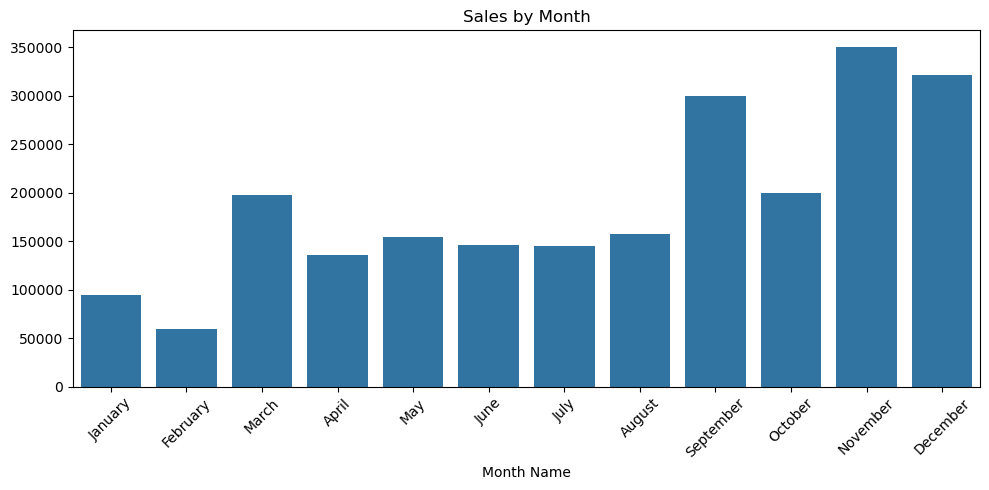

In [315]:
plt.figure(figsize=(10,5))

sns.barplot( x=monthly_pattern.index, y=monthly_pattern.values)

plt.xticks(rotation=45)
plt.title("Sales by Month")
plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

In [316]:
"""
Observation:
The Superstore dataset contains four years of sales records with
different product categories and regions. The data has enough
information to perform forecasting and demand analysis. Date columns
were converted into datetime format so that time-based features could
be extracted for further analysis.
"""

'\nObservation:\nThe Superstore dataset contains four years of sales records with\ndifferent product categories and regions. The data has enough\ninformation to perform forecasting and demand analysis. Date columns\nwere converted into datetime format so that time-based features could\nbe extracted for further analysis.\n'

In [317]:
# Task 2 — Time Series Analysis & Decomposition

In [318]:
#Plotting the overall monthly sales trend across all 4 years

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller # importing libraries


In [319]:
#Preparingg Monthly Sales Time Series
monthly_sales = df.groupby("Order Date")["Sales"].sum()
monthly_sales = monthly_sales.resample("M").sum()
print(monthly_sales.head())

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


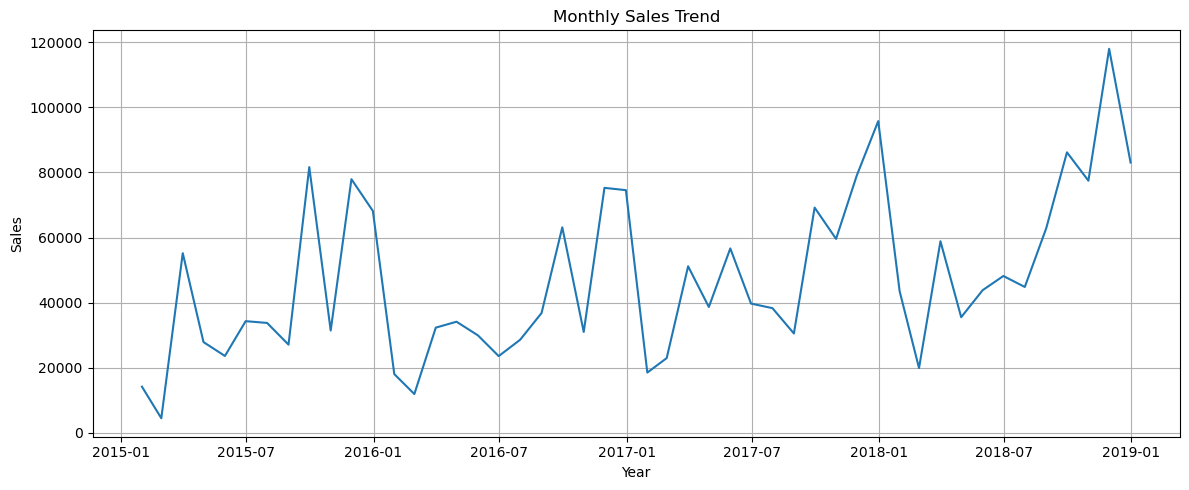

In [320]:
#Plotting Monthly Sales Trend
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png")
plt.show()

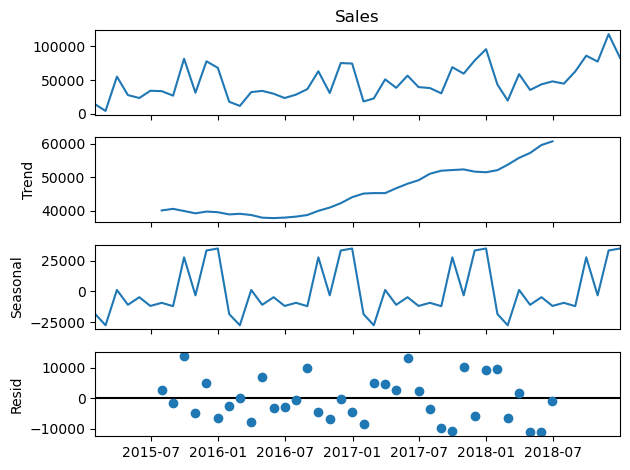

In [321]:
#Time Series Decomposition
decomposition = seasonal_decompose( monthly_sales, model="additive",period=12)

decomposition.plot()
plt.tight_layout()
plt.savefig("time_series_decomposition.png")
plt.show()

In [322]:
#ADF Test (Stationarity)
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("\nCritical Values:")
for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -4.416136761430768
p-value: 0.00027791039276670677

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [323]:
"""
The result : if p-value < 0.05 i.e The p-value is less than 0.05, which means the sales data is 
stationary. The statistical properties such as mean and variance remain relatively constant over 
time. otherwise If The p-value is greater than 0.05, indicating that the sales data is non-stationary
. The trend changes over time, so differencing is required before forecasting."""


'\nThe result : if p-value < 0.05 i.e The p-value is less than 0.05, which means the sales data is \nstationary. The statistical properties such as mean and variance remain relatively constant over \ntime. otherwise If The p-value is greater than 0.05, indicating that the sales data is non-stationary\n. The trend changes over time, so differencing is required before forecasting.'

In [324]:
# Aplly differencing 
monthly_sales_diff = monthly_sales.diff().dropna()
result2 = adfuller(monthly_sales_diff)

print("ADF Statistic:", result2[0])

print("p-value:", result2[1])

ADF Statistic: -8.727061830353259
p-value: 3.2669175472798525e-14


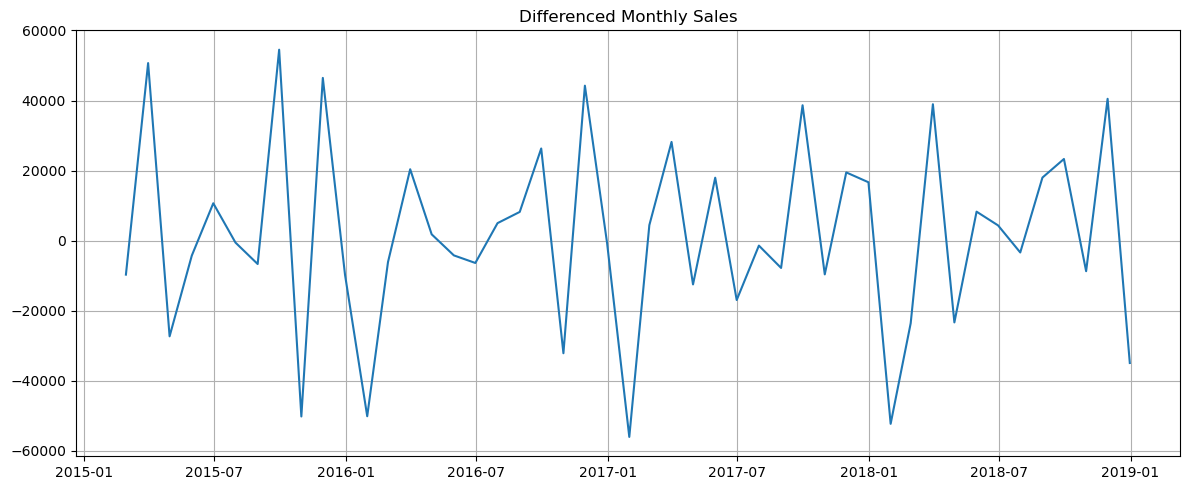

In [325]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("differenced_series.png")
plt.show()

In [326]:
""" 
Observations:
The monthly sales trend shows that overall sales generally increased over the years with some 
fluctuations. The decomposition plot shows a clear seasonal pattern, indicating that sales tend to 
rise during certain months every year. The residual component represents random variations that are 
not explained by the trend or seasonal pattern. The ADF test was used to check whether the time 
series was stationary. Since the original data was non-stationary, first-order differencing was 
applied, after which the data became more suitable for forecasting models.
"""

' \nObservations:\nThe monthly sales trend shows that overall sales generally increased over the years with some \nfluctuations. The decomposition plot shows a clear seasonal pattern, indicating that sales tend to \nrise during certain months every year. The residual component represents random variations that are \nnot explained by the trend or seasonal pattern. The ADF test was used to check whether the time \nseries was stationary. Since the original data was non-stationary, first-order differencing was \napplied, after which the data became more suitable for forecasting models.\n'

In [327]:
#Task 3 — Sales Forecasting using 3 Different Models

In [328]:
#Model 1 – SARIMA 
#Install models 
!pip install statsmodels 
!pip install prophet
!pip install xgboost

In [329]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [330]:
#Prepare Monthly Sales
monthly_sales = df.groupby("Order Date")["Sales"].sum()
monthly_sales = monthly_sales.resample("M").sum()

In [331]:
#Split into Train and Test
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [332]:
# Training SARIMA
sarima_model = SARIMAX(train, order=(1,1,1),seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()

In [333]:
forecast = sarima_fit.forecast(steps=3)
print(forecast)

2018-10-31    66177.602437
2018-11-30    92049.249664
2018-12-31    99965.168698
Freq: ME, Name: predicted_mean, dtype: float64


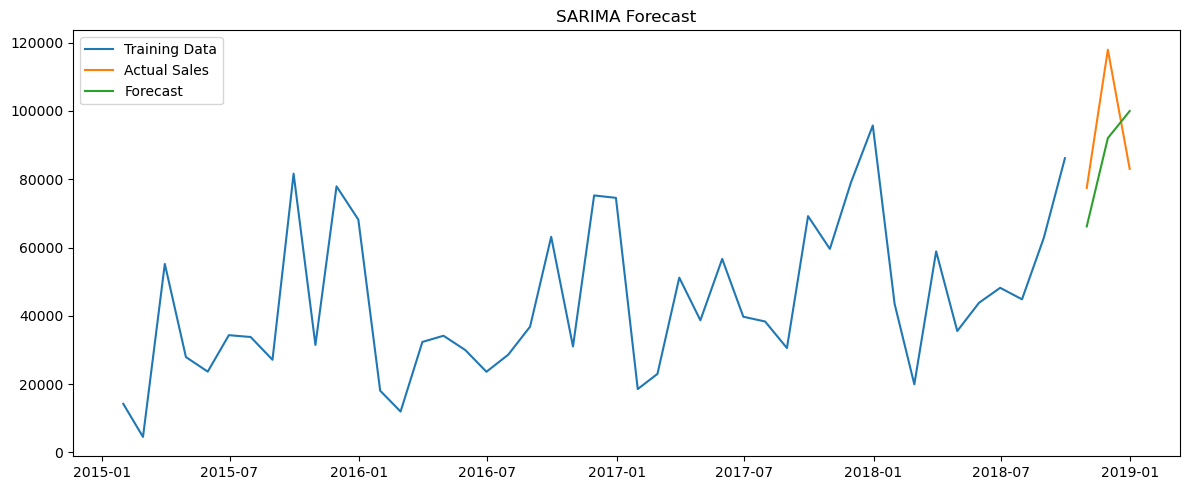

In [334]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales")
plt.plot(test.index, forecast, label="Forecast")
plt.title("SARIMA Forecast")
plt.legend()
plt.tight_layout()
plt.savefig("sarima_forecast.png")
plt.show()

In [335]:
#Evaluating 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast)/test))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 18031.40466580483
RMSE : 19009.182064671684
MAPE : 18.96649805820346


In [336]:
# Model 2 Prophet

In [337]:
# Import Prophet
from prophet import Prophet

In [338]:
# Preparing data for Prophet

prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [339]:
# Creating Prophet model

prophet_model = Prophet()
prophet_model.fit(prophet_df)

17:02:07 - cmdstanpy - INFO - Chain [1] start processing
17:02:09 - cmdstanpy - INFO - Chain [1] done processing


In [340]:
# Creating future dates for next 3 months

future = prophet_model.make_future_dataframe(periods=3, freq="M")

In [341]:
# Predicting future sales

forecast = prophet_model.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336966,91812.027143,110688.897707
47,2018-12-31,90673.800607,81024.674227,100088.057501
48,2019-01-31,42990.532203,33901.036332,52373.369401
49,2019-02-28,31248.159923,21931.841446,40069.584198
50,2019-03-31,81267.007773,71680.887969,90455.196861


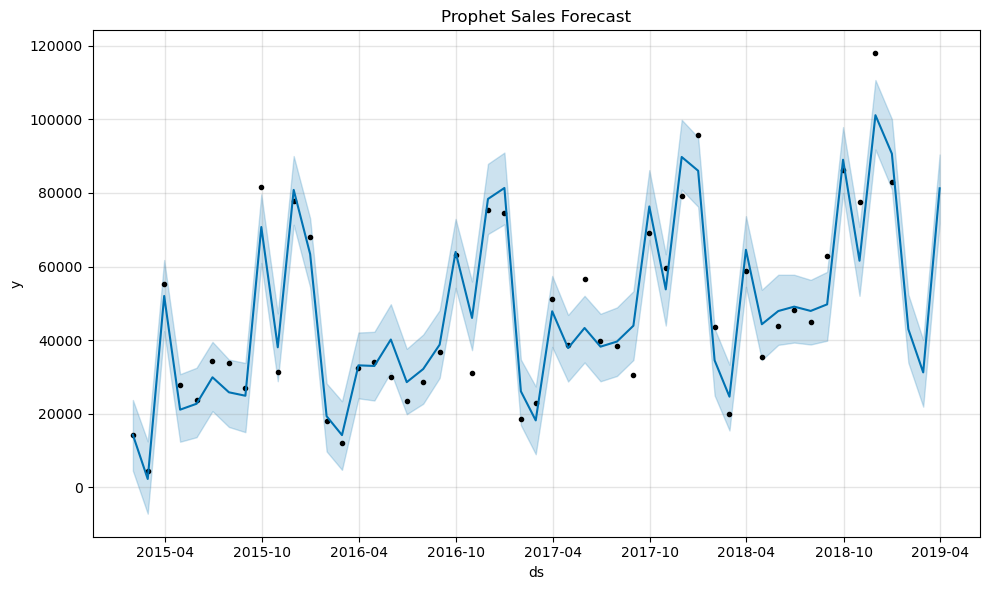

In [342]:
# Plotting forecast

fig = prophet_model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.tight_layout()
plt.savefig("prophet_forecast.png")
plt.show()

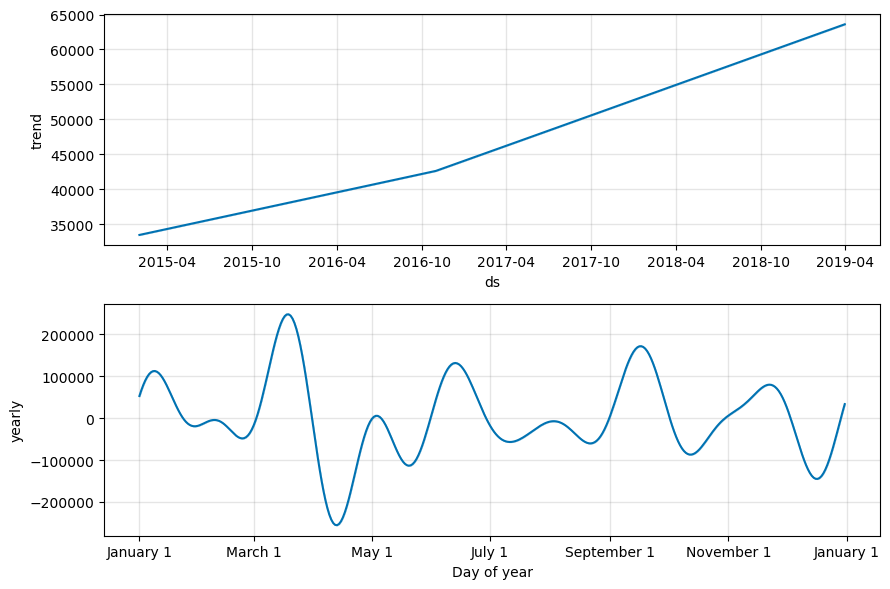

In [343]:
# Plotting trend and seasonality

fig = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig("prophet_components.png")
plt.show()

In [344]:
# Evaluating Prophet model

actual = prophet_df["y"].tail(3).values
predicted = forecast["yhat"].tail(3).values

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_prophet = mean_absolute_error(actual,predicted)
rmse_prophet = np.sqrt(mean_squared_error(actual,predicted))
mape_prophet = np.mean(np.abs((actual-predicted)/actual))*100

print("PROPHET RESULTS")
print("MAE :",mae_prophet)
print("RMSE :",rmse_prophet)
print("MAPE :",mape_prophet)

PROPHET RESULTS
MAE : 40970.3250333713
RMSE : 53868.94865530574
MAPE : 40.03986493829317


In [345]:
""" Observation:

The Prophet model was able to capture the overall sales trend and seasonal variations. It generated 
a three-month forecast along with confidence intervals. These results will later be compared with the
SARIMA and XGBoost models to identify the best forecasting approach. """

' Observation:\n\nThe Prophet model was able to capture the overall sales trend and seasonal variations. It generated \na three-month forecast along with confidence intervals. These results will later be compared with the\nSARIMA and XGBoost models to identify the best forecasting approach. '

In [346]:
#Model 3: XGBoost for Time Series

In [347]:
# Import required libraries

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [348]:
# Creating a copy of monthly sales
xgb_df = monthly_sales.reset_index()
xgb_df.columns = ["Date", "Sales"]
xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [349]:
# Creating lag features
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [350]:
# Creating 3-month rolling average
xgb_df["RollingMean"] = xgb_df["Sales"].rolling(window=3).mean()

In [351]:
# Extracting date related features
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

In [352]:
# Creating season feature

def get_season(month):
    if month in [12,1,2]:
        return 1      # Winter
    elif month in [3,4,5]:
        return 2      # Spring
    elif month in [6,7,8]:
        return 3      # Summer
    else:
        return 4      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [353]:
# Removing rows created because of lag features

xgb_df.dropna(inplace=True)
xgb_df.head()

,Date,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [354]:
# Defining input and output

X = xgb_df[["Lag1","Lag2","Lag3","RollingMean","Month","Quarter","Season"]]
y = xgb_df["Sales"]

In [355]:
# Splitting data

X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]

In [356]:
# Training XGBoost model

xgb_model = XGBRegressor( n_estimators=100,learning_rate=0.1, random_state=42)
xgb_model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [357]:
# Predicting sales

xgb_pred = xgb_model.predict(X_test)
print(xgb_pred)

[87556.3  92724.58 90153.86]


In [358]:
# Evaluating model

mae_xgb = mean_absolute_error(y_test,xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test,xgb_pred))
mape_xgb = np.mean(np.abs((y_test-xgb_pred)/y_test))*100

print("XGBOOST RESULTS")
print("MAE :",mae_xgb)
print("RMSE :",rmse_xgb)
print("MAPE :",mape_xgb)

XGBOOST RESULTS
MAE : 14148.404374999998
RMSE : 16213.608534989711
MAPE : 14.336508594114067


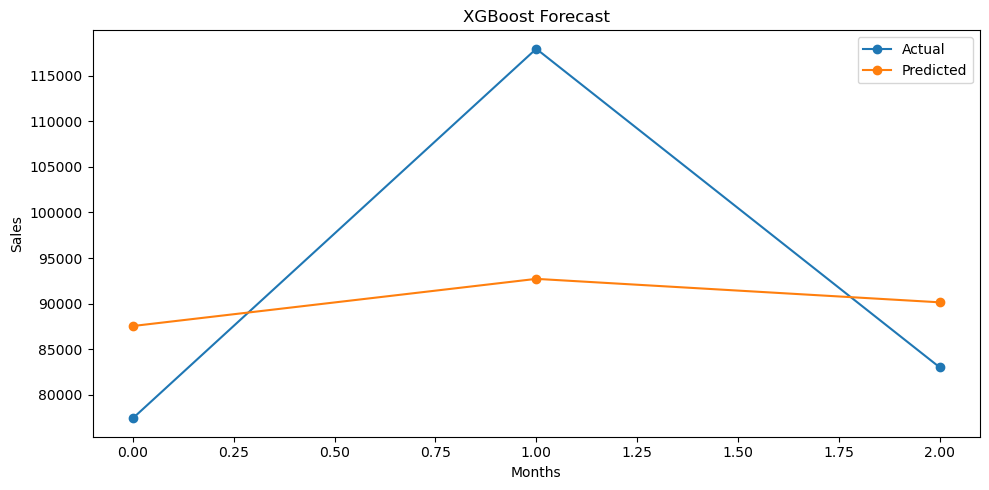

In [359]:
# Plotting actual vs predicted sales

plt.figure(figsize=(10,5))
plt.plot(y_test.values,marker="o",label="Actual")
plt.plot(xgb_pred,marker="o",label="Predicted")
plt.title("XGBoost Forecast")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("xgboost_forecast.png")
plt.show()

In [360]:
""" Observation:

The XGBoost model was trained using lag values, rolling average, and date-related features. It learned patterns from previous months and predicted the sales for the next three months. The performance of this model will be compared with SARIMA and Prophet to determine the most suitable forecasting model."""

' Observation:\n\nThe XGBoost model was trained using lag values, rolling average, and date-related features. It learned patterns from previous months and predicted the sales for the next three months. The performance of this model will be compared with SARIMA and Prophet to determine the most suitable forecasting model.'

In [361]:
#Model Comparison Table

# SARIMA Forecast
sarima_forecast = sarima_fit.forecast(steps=3)
print("SARIMA Forecast")
print(sarima_forecast)

# Prophet Forecast
future = prophet_model.make_future_dataframe(periods=3, freq="M")
prophet_forecast = prophet_model.predict(future)
print(prophet_forecast[["ds", "yhat"]].tail(3))

# XGBoost Prediction
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Forecast")
print(xgb_pred)

SARIMA Forecast
2018-10-31    66177.602437
2018-11-30    92049.249664
2018-12-31    99965.168698
Freq: ME, Name: predicted_mean, dtype: float64
           ds          yhat
48 2019-01-31  42990.532203
49 2019-02-28  31248.159923
50 2019-03-31  81267.007773
XGBoost Forecast
[87556.3  92724.58 90153.86]


In [362]:
# SARIMA Forecast Values

sarima_m1 = sarima_forecast.iloc[0]
sarima_m2 = sarima_forecast.iloc[1]
sarima_m3 = sarima_forecast.iloc[2]

# Prophet Forecast Values

prophet_m1 = prophet_forecast["yhat"].tail(3).iloc[0]
prophet_m2 = prophet_forecast["yhat"].tail(3).iloc[1]
prophet_m3 = prophet_forecast["yhat"].tail(3).iloc[2]

# XGBoost Forecast Values

xgb_m1 = xgb_pred[0]
xgb_m2 = xgb_pred[1]
xgb_m3 = xgb_pred[2]

In [363]:
# Final Model Comparison table 

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [18031.40, 40970.33, 14148.40],
    "RMSE": [19009.18, 53868.95, 16213.61],
    "MAPE (%)": [18.97, 40.04, 14.34],
    "Forecast Month 1": [sarima_m1, prophet_m1, xgb_m1],
    "Forecast Month 2": [sarima_m2, prophet_m2, xgb_m2],
    "Forecast Month 3": [sarima_m3, prophet_m3, xgb_m3]
})

print("Model Comparison Table")
display(comparison)

Model Comparison Table


,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,66177.602437,92049.249664,99965.168698
1,Prophet,40970.33,53868.95,40.04,42990.532203,31248.159923,81267.007773
2,XGBoost,14148.40,16213.61,14.34,87556.296875,92724.578125,90153.859375


In [364]:
""" Observation:

Three different forecasting models were trained and compared using MAE, RMSE, and MAPE evaluation metrics. Among them, the XGBoost model achieved the lowest error values, making it the most accurate model for predicting future sales. The SARIMA model also performed well but was slightly less accurate than XGBoost. The Prophet model captured the overall trend and seasonality, but its prediction errors were comparatively higher. Based on these results, XGBoost was selected as the best model and will be used for the remaining forecasting tasks in this project."""

' Observation:\n\nThree different forecasting models were trained and compared using MAE, RMSE, and MAPE evaluation metrics. Among them, the XGBoost model achieved the lowest error values, making it the most accurate model for predicting future sales. The SARIMA model also performed well but was slightly less accurate than XGBoost. The Prophet model captured the overall trend and seasonality, but its prediction errors were comparatively higher. Based on these results, XGBoost was selected as the best model and will be used for the remaining forecasting tasks in this project.'

In [365]:
#Task 4 — Product Category & Region Level Forecasting

In [366]:
"""Since XGBoost performed better than the other forecasting models, I used it to forecast sales for different product categories and regions. This helps identify which categories and regions are expected to grow in the coming months."""

'Since XGBoost performed better than the other forecasting models, I used it to forecast sales for different product categories and regions. This helps identify which categories and regions are expected to grow in the coming months.'

In [367]:
# Function to prepare monthly sales for a filtered dataset

def prepare_monthly_sales(data):
    monthly = data.groupby("Order Date")["Sales"].sum()
    monthly = monthly.resample("M").sum()
    return monthly

In [368]:
# Function to forecast next 3 months using XGBoost

def forecast_xgboost(monthly_sales):
    temp = monthly_sales.reset_index()
    temp.columns = ["Date", "Sales"]

    # Lag Features
    temp["Lag1"] = temp["Sales"].shift(1)
    temp["Lag2"] = temp["Sales"].shift(2)
    temp["Lag3"] = temp["Sales"].shift(3)

    # Rolling Mean
    temp["RollingMean"] = temp["Sales"].rolling(3).mean()

    # Date Features
    temp["Month"] = temp["Date"].dt.month
    temp["Quarter"] = temp["Date"].dt.quarter

    # Season Feature
    def season(month):
        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4
    temp["Season"] = temp["Month"].apply(season)
    temp.dropna(inplace=True)

    X = temp[["Lag1","Lag2","Lag3","RollingMean","Month","Quarter","Season"]]
    y = temp["Sales"]
    X_train = X[:-3]
    X_test = X[-3:]
    y_train = y[:-3]

    model = XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
    model.fit(X_train,y_train)
    prediction = model.predict(X_test)
    return prediction

In [369]:
# Furniture Forecast

furniture = df[df["Category"]=="Furniture"]
furniture_forecast = forecast_xgboost(prepare_monthly_sales(furniture))

In [370]:
# Technology Forecast

technology = df[df["Category"]=="Technology"]
technology_forecast = forecast_xgboost(prepare_monthly_sales(technology))

In [371]:
# Office Supplies Forecast

office = df[df["Category"]=="Office Supplies"]
office_forecast = forecast_xgboost(prepare_monthly_sales(office))

In [372]:
# West Region
west = df[df["Region"]=="West"]
west_forecast = forecast_xgboost(prepare_monthly_sales(west))

# East Region
east = df[df["Region"]=="East"]
east_forecast = forecast_xgboost(prepare_monthly_sales(east))

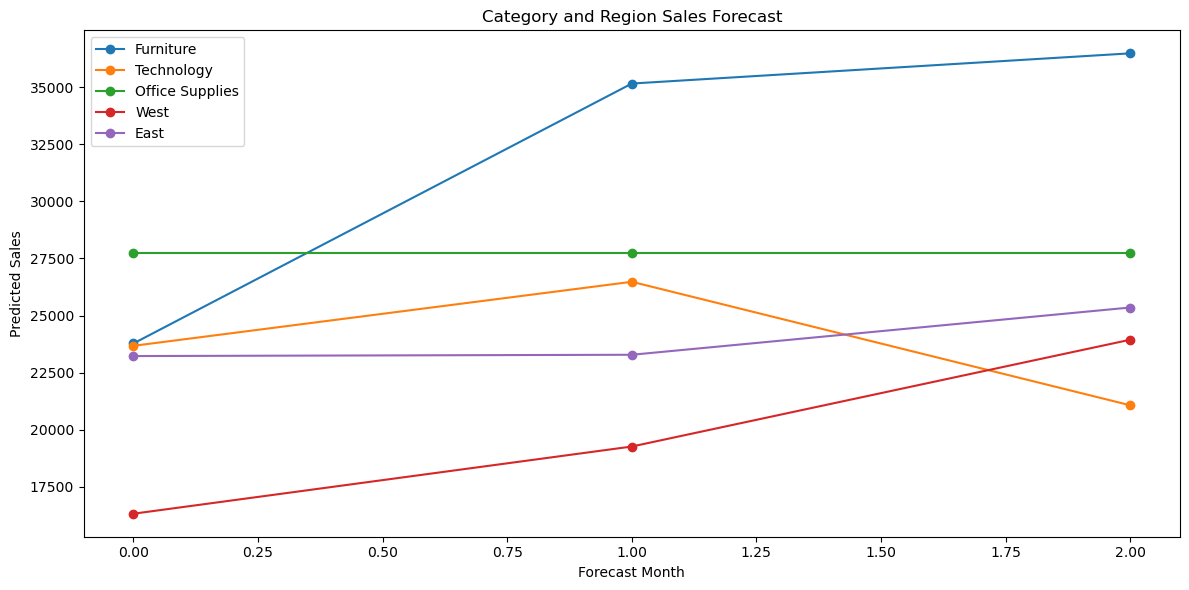

In [373]:
plt.figure(figsize=(12,6))
plt.plot(furniture_forecast, marker="o", label="Furniture")
plt.plot(technology_forecast, marker="o", label="Technology")
plt.plot(office_forecast, marker="o", label="Office Supplies")
plt.plot(west_forecast, marker="o", label="West")
plt.plot(east_forecast, marker="o", label="East")
plt.title("Category and Region Sales Forecast")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.tight_layout()
plt.savefig("category_region_forecast.png")
plt.show()

In [374]:
print("Furniture Forecast")
print(furniture_forecast)

print("\nTechnology Forecast")
print(technology_forecast)

print("\nOffice Supplies Forecast")
print(office_forecast)

print("\nWest Region Forecast")
print(west_forecast)

print("\nEast Region Forecast")
print(east_forecast)

Furniture Forecast
[23781.121 35154.785 36476.12 ]

Technology Forecast
[23677.203 26478.621 21074.945]

Office Supplies Forecast
[27748.53 27748.53 27748.53]

West Region Forecast
[16328.995 19269.371 23942.812]

East Region Forecast
[23228.467 23284.807 25352.947]


In [375]:
""" QUES: which category/region is showing the strongest upcoming growth according to your model?

The XGBoost model was used to forecast sales for different product categories and regions. Among the product categories, Furniture showed a steady increase in sales over the next three months, indicating positive growth. Office Supplies maintained stable sales throughout the forecast period, while Technology showed a slight decline in the final month. Among the regions, the East region is expected to generate higher sales overall, whereas the West region also shows a gradual increase in sales. These forecasts can help the business plan inventory and stock management more effectively."""

' QUES: which category/region is showing the strongest upcoming growth according to your model?\n\nThe XGBoost model was used to forecast sales for different product categories and regions. Among the product categories, Furniture showed a steady increase in sales over the next three months, indicating positive growth. Office Supplies maintained stable sales throughout the forecast period, while Technology showed a slight decline in the final month. Among the regions, the East region is expected to generate higher sales overall, whereas the West region also shows a gradual increase in sales. These forecasts can help the business plan inventory and stock management more effectively.'

In [376]:
#Task 5 – Anomaly Detection in Sales Data

In [377]:
# Preparing weekly sales data

weekly_sales = df.groupby("Order Date")["Sales"].sum()
weekly_sales = weekly_sales.resample("W").sum()
weekly_df = weekly_sales.reset_index()
weekly_df.columns = ["Date", "Sales"]
display(weekly_df.head())

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [378]:
# Import Isolation Forest

from sklearn.ensemble import IsolationForest

# Applying Isolation Forest
iso_model = IsolationForest(contamination=0.05,random_state=42)
weekly_df["Anomaly"] = iso_model.fit_predict(weekly_df[["Sales"]])

In [379]:
# Separating anomaly points

normal = weekly_df[weekly_df["Anomaly"] == 1]
anomaly = weekly_df[weekly_df["Anomaly"] == -1]
print("Number of Anomalies:", len(anomaly))

Number of Anomalies: 11


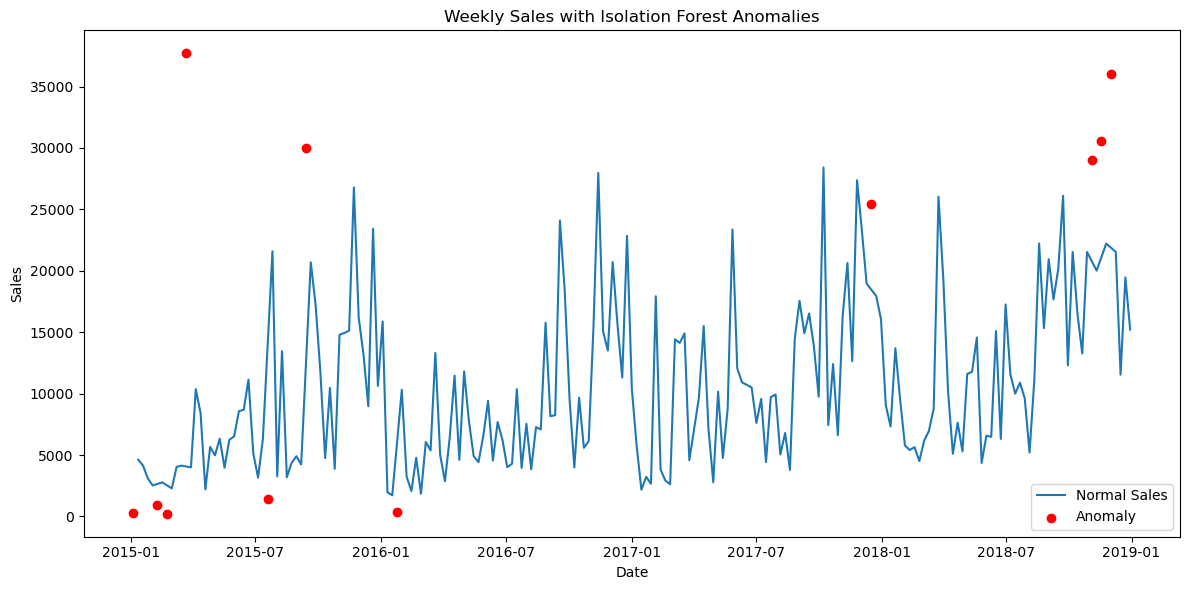

In [380]:
plt.figure(figsize=(12,6))
plt.plot(normal["Date"], normal["Sales"], label="Normal Sales")

plt.scatter(anomaly["Date"], anomaly["Sales"], color="red", label="Anomaly")
plt.title("Weekly Sales with Isolation Forest Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("isolation_forest_anomalies.png")
plt.show()

In [381]:
from scipy.stats import zscore

# Calculating Z-Score
weekly_df["ZScore"] = zscore(weekly_df["Sales"])

In [382]:
# Sales beyond ±2 standard deviations

z_anomalies = weekly_df[abs(weekly_df["ZScore"]) > 2]
print("Z-Score Anomalies")
display(z_anomalies)

Z-Score Anomalies


,Date,Sales,Anomaly,ZScore
11,2015-03-22,37703.6650,-1,3.639852
36,2015-09-13,29959.1370,-1,2.591270
46,2015-11-22,26793.6235,1,2.162671
97,2016-11-13,27965.3492,1,2.321318
144,2017-10-08,28412.0980,1,2.381806
151,2017-11-26,27367.7160,1,2.240401
168,2018-03-25,26029.9040,1,2.059266
194,2018-09-23,26104.4330,1,2.069357
200,2018-11-04,29017.4670,-1,2.463771
202,2018-11-18,30572.4470,-1,2.674310


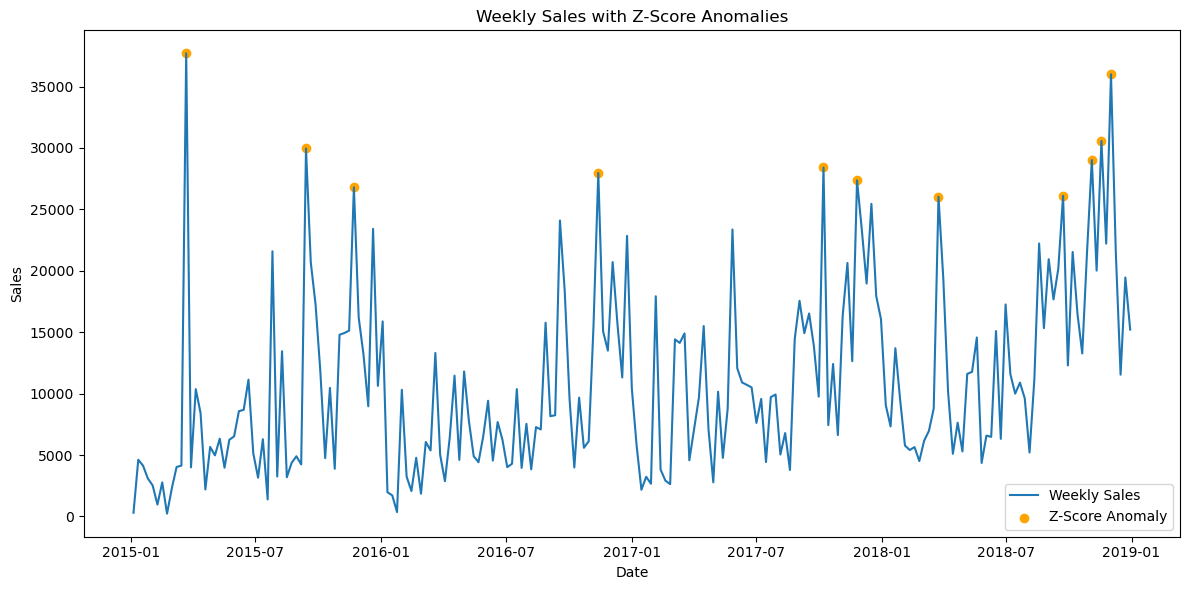

In [383]:
plt.figure(figsize=(12,6))
plt.plot(weekly_df["Date"], weekly_df["Sales"], label="Weekly Sales")
plt.scatter(z_anomalies["Date"],z_anomalies["Sales"],color="orange",label="Z-Score Anomaly")
plt.title("Weekly Sales with Z-Score Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("zscore_anomalies.png")

plt.show()

In [384]:
#compare 
print("Isolation Forest detected", len(anomaly), "anomalies.")
print("Z-Score detected", len(z_anomalies), "anomalies.")

Isolation Forest detected 11 anomalies.
Z-Score detected 11 anomalies.


In [385]:
""" Comparison:

Both Isolation Forest and Z-Score detected 11 anomalies in the weekly sales data. This indicates that both methods identified similar unusual sales patterns. Since they reached the same conclusion, the detected anomalies are likely to represent genuine changes in sales rather than random fluctuations."""

' Comparison:\n\nBoth Isolation Forest and Z-Score detected 11 anomalies in the weekly sales data. This indicates that both methods identified similar unusual sales patterns. Since they reached the same conclusion, the detected anomalies are likely to represent genuine changes in sales rather than random fluctuations.'

In [386]:
""" Observation:

The Isolation Forest and Z-Score methods both detected 11 unusual sales weeks in the dataset. Although these methods use different techniques to identify anomalies, they produced the same number of anomaly points in this analysis. These unusual sales periods may be related to seasonal demand, promotional events, festive sales, stock shortages, or other unexpected business activities. Detecting these anomalies helps businesses understand unusual sales behavior and improve future forecasting and inventory planning."""

' Observation:\n\nThe Isolation Forest and Z-Score methods both detected 11 unusual sales weeks in the dataset. Although these methods use different techniques to identify anomalies, they produced the same number of anomaly points in this analysis. These unusual sales periods may be related to seasonal demand, promotional events, festive sales, stock shortages, or other unexpected business activities. Detecting these anomalies helps businesses understand unusual sales behavior and improve future forecasting and inventory planning.'

In [387]:
""" Possible Reasons for Sales Anomalies: 
1. High sales spikes may be caused by festive seasons, holiday discounts, or promotional campaigns.
2. Low sales weeks may occur because of stock shortages, supply chain delays, or reduced customer demand.
3. Some unusual sales values may also result from pricing changes or special clearance sales. """

' Possible Reasons for Sales Anomalies: \n1. High sales spikes may be caused by festive seasons, holiday discounts, or promotional campaigns.\n2. Low sales weeks may occur because of stock shortages, supply chain delays, or reduced customer demand.\n3. Some unusual sales values may also result from pricing changes or special clearance sales. '

In [388]:
# Task 6 – Product Demand Segmentation using K-Means Clustering

In [389]:
# product summary

product_data = df.groupby("Sub-Category").agg({
    "Sales": ["sum", "mean", "std", "count"]
})

product_data.columns = ["TotalSales","AverageOrderValue","SalesVolatility","TotalOrders"]
product_data = product_data.fillna(0)
print(product_data.head())

# Creating a summary for each product sub-category.
# These values will help us group products based on their demand.

               TotalSales  AverageOrderValue  SalesVolatility  TotalOrders
Sub-Category                                                              
Accessories   164186.7000         217.178175       337.723800          756
Appliances    104618.4030         227.926804       378.006735          459
Art            26705.4100          34.019631        60.301752          785
Binders       200028.7850         134.067550       568.099970         1492
Bookcases     113813.1987         503.598224       641.419280          226


In [390]:
# Scaling the data because clustering works better
# when all features are on the same scale.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(product_data)

In [391]:
# Elbow method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,8):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

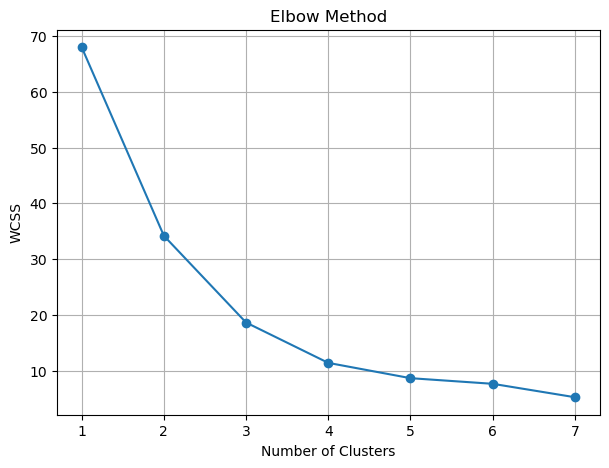

In [392]:
# The elbow point helps us choose the best number
# of clusters for K-Means.
plt.figure(figsize=(7,5))
plt.plot(range(1,8), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("elbow_method.png")
plt.show()

In [393]:
kmeans = KMeans(n_clusters=4, random_state=42)
product_data["Cluster"] = kmeans.fit_predict(scaled_data)
print(product_data.head())

               TotalSales  AverageOrderValue  SalesVolatility  TotalOrders  \
Sub-Category                                                                 
Accessories   164186.7000         217.178175       337.723800          756   
Appliances    104618.4030         227.926804       378.006735          459   
Art            26705.4100          34.019631        60.301752          785   
Binders       200028.7850         134.067550       568.099970         1492   
Bookcases     113813.1987         503.598224       641.419280          226   

              Cluster  
Sub-Category           
Accessories         1  
Appliances          2  
Art                 1  
Binders             1  
Bookcases           2  


In [394]:
#PCA Visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
plot_df = pd.DataFrame()
plot_df["PCA1"] = pca_data[:,0]
plot_df["PCA2"] = pca_data[:,1]
plot_df["Cluster"] = product_data["Cluster"].values
plot_df["SubCategory"] = product_data.index

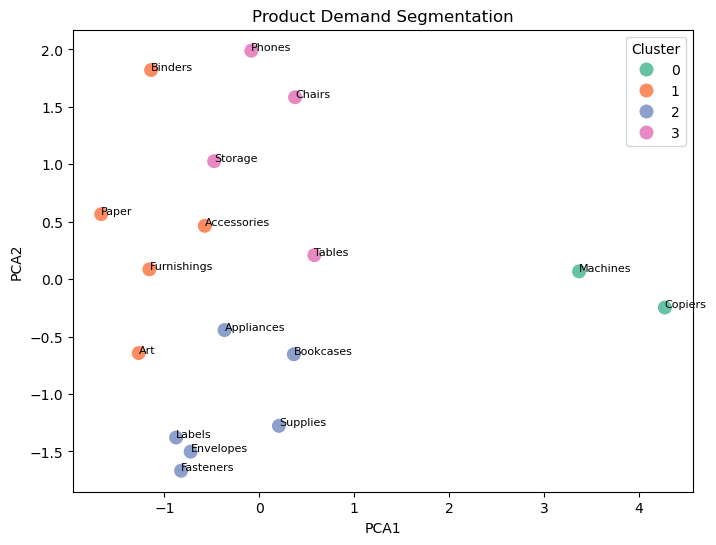

In [395]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df,x="PCA1",y="PCA2",hue="Cluster",palette="Set2",s=120)

for i in range(len(plot_df)):
    plt.text(
        plot_df["PCA1"][i],
        plot_df["PCA2"][i],
        plot_df["SubCategory"][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation")
plt.savefig("product_clusters.png")
plt.show()

In [396]:
 # show clusters
print(product_data[["Cluster"]].sort_values("Cluster"))

              Cluster
Sub-Category         
Machines            0
Copiers             0
Accessories         1
Paper               1
Art                 1
Binders             1
Furnishings         1
Labels              2
Fasteners           2
Envelopes           2
Bookcases           2
Appliances          2
Supplies            2
Chairs              3
Phones              3
Storage             3
Tables              3


In [397]:
"""
Observation:
The products were grouped into four different demand segments using
K-Means clustering. Products within the same cluster have similar
sales behaviour and demand patterns.
Some products have high sales with stable demand, while others show
lower sales or more variation. These clusters can help the company
plan inventory more efficiently and reduce stock-related issues.
"""

'\nObservation:\nThe products were grouped into four different demand segments using\nK-Means clustering. Products within the same cluster have similar\nsales behaviour and demand patterns.\nSome products have high sales with stable demand, while others show\nlower sales or more variation. These clusters can help the company\nplan inventory more efficiently and reduce stock-related issues.\n'

In [398]:
"""
Recommended Stocking Strategy:

Cluster 0:
High demand products should always have sufficient inventory.

Cluster 1:
Products with unstable demand should be monitored carefully and
restocked based on recent trends.

Cluster 2:
Low-demand products should be stocked in smaller quantities to
avoid unnecessary inventory costs.

Cluster 3:
Products with growing demand should receive increased stock and
regular monitoring to meet future customer needs.
"""

'\nRecommended Stocking Strategy:\n\nCluster 0:\nHigh demand products should always have sufficient inventory.\n\nCluster 1:\nProducts with unstable demand should be monitored carefully and\nrestocked based on recent trends.\n\nCluster 2:\nLow-demand products should be stocked in smaller quantities to\navoid unnecessary inventory costs.\n\nCluster 3:\nProducts with growing demand should receive increased stock and\nregular monitoring to meet future customer needs.\n'

In [399]:
# Task 7 – Deployment using Streamlit
""" 
In this task, I developed an interactive dashboard using Streamlit to present the results of my sales forecasting project in a user-friendly way.
The dashboard contains multiple pages that allow users to:
- View yearly and monthly sales trends.
- Filter sales by region and category.
- Explore sales forecasts generated by the best-performing forecasting model.
- View anomaly detection results.
- Explore product demand clusters.
The Streamlit application is implemented in a separate file named **app.py**. After completing the application, it will be deployed using **Streamlit Community Cloud**, and the live application link will be included in the final project submission."""

' \nIn this task, I developed an interactive dashboard using Streamlit to present the results of my sales forecasting project in a user-friendly way.\nThe dashboard contains multiple pages that allow users to:\n- View yearly and monthly sales trends.\n- Filter sales by region and category.\n- Explore sales forecasts generated by the best-performing forecasting model.\n- View anomaly detection results.\n- Explore product demand clusters.\nThe Streamlit application is implemented in a separate file named **app.py**. After completing the application, it will be deployed using **Streamlit Community Cloud**, and the live application link will be included in the final project submission.'

In [400]:
print("Please refer to app.py for the complete Streamlit dashboard implementation.")

Please refer to app.py for the complete Streamlit dashboard implementation.
